In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [2]:
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
len(words)

32033

In [4]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s, i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [5]:
# build the dataset
block_size = 3 # context length of how many characters we take to predict the next one

X, Y = [], []
for w in words[:5]:
    print(w)
    context = [0] * block_size # first iteration: context -> [0, 0, 0]
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        print(''.join(itos[i] for i in context), '------>', itos[ix])
        context = context[1:] + [ix]

X = torch.tensor(X)
Y = torch.tensor(Y)

emma
... ------> e
..e ------> m
.em ------> m
emm ------> a
mma ------> .
olivia
... ------> o
..o ------> l
.ol ------> i
oli ------> v
liv ------> i
ivi ------> a
via ------> .
ava
... ------> a
..a ------> v
.av ------> a
ava ------> .
isabella
... ------> i
..i ------> s
.is ------> a
isa ------> b
sab ------> e
abe ------> l
bel ------> l
ell ------> a
lla ------> .
sophia
... ------> s
..s ------> o
.so ------> p
sop ------> h
oph ------> i
phi ------> a
hia ------> .


In [10]:
# w = 'emma.'
# X = [[0, 0, 0]]
# Y = [5]
# context = [0, 0, 5]

In [6]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([32, 3]), torch.int64, torch.Size([32]), torch.int64)

In [7]:
print(X)

tensor([[ 0,  0,  0],
        [ 0,  0,  5],
        [ 0,  5, 13],
        [ 5, 13, 13],
        [13, 13,  1],
        [ 0,  0,  0],
        [ 0,  0, 15],
        [ 0, 15, 12],
        [15, 12,  9],
        [12,  9, 22],
        [ 9, 22,  9],
        [22,  9,  1],
        [ 0,  0,  0],
        [ 0,  0,  1],
        [ 0,  1, 22],
        [ 1, 22,  1],
        [ 0,  0,  0],
        [ 0,  0,  9],
        [ 0,  9, 19],
        [ 9, 19,  1],
        [19,  1,  2],
        [ 1,  2,  5],
        [ 2,  5, 12],
        [ 5, 12, 12],
        [12, 12,  1],
        [ 0,  0,  0],
        [ 0,  0, 19],
        [ 0, 19, 15],
        [19, 15, 16],
        [15, 16,  8],
        [16,  8,  9],
        [ 8,  9,  1]])


In [8]:
Y

tensor([ 5, 13, 13,  1,  0, 15, 12,  9, 22,  9,  1,  0,  1, 22,  1,  0,  9, 19,
         1,  2,  5, 12, 12,  1,  0, 19, 15, 16,  8,  9,  1,  0])

In [9]:
C = torch.randn((27, 2))

In [ ]:
C 
# C is a character embedding table from 0 to 26 C[0] is a 
# 2 dimensional vector representing the character '.'

tensor([[ 1.0968, -0.7781],
        [ 0.6379,  0.5293],
        [ 0.1861,  0.1720],
        [-0.4430,  0.7965],
        [-0.4411,  2.3345],
        [-1.3490,  0.7312],
        [-1.5422, -0.9690],
        [ 0.3098, -0.3229],
        [ 0.4053, -0.6974],
        [-0.9478, -1.4288],
        [-1.0453,  0.7968],
        [ 1.2045,  0.0595],
        [ 2.2601, -1.5945],
        [-0.2551, -1.5857],
        [ 0.2454,  1.0321],
        [ 0.3263,  1.3796],
        [ 0.3118,  0.0709],
        [-0.5017,  0.5514],
        [ 0.9387, -0.2080],
        [ 1.3771,  0.2535],
        [ 0.7480, -0.0834],
        [ 1.9816, -0.8220],
        [-2.3402,  1.6473],
        [ 0.9969, -0.2356],
        [-1.5413, -0.5456],
        [ 0.3636, -1.2307],
        [ 0.1740, -0.8555]])

In [ ]:
emb = C[X] # special way of indexing in pytorch
print(emb.shape)
emb
# (N, 3, 2) 
# N -> # of training examples
# 3 -> three characters in each context
# 2 -> two embedding values for each character

torch.Size([32, 3, 2])


tensor([[[ 1.0968, -0.7781],
         [ 1.0968, -0.7781],
         [ 1.0968, -0.7781]],

        [[ 1.0968, -0.7781],
         [ 1.0968, -0.7781],
         [-1.3490,  0.7312]],

        [[ 1.0968, -0.7781],
         [-1.3490,  0.7312],
         [-0.2551, -1.5857]],

        [[-1.3490,  0.7312],
         [-0.2551, -1.5857],
         [-0.2551, -1.5857]],

        [[-0.2551, -1.5857],
         [-0.2551, -1.5857],
         [ 0.6379,  0.5293]],

        [[ 1.0968, -0.7781],
         [ 1.0968, -0.7781],
         [ 1.0968, -0.7781]],

        [[ 1.0968, -0.7781],
         [ 1.0968, -0.7781],
         [ 0.3263,  1.3796]],

        [[ 1.0968, -0.7781],
         [ 0.3263,  1.3796],
         [ 2.2601, -1.5945]],

        [[ 0.3263,  1.3796],
         [ 2.2601, -1.5945],
         [-0.9478, -1.4288]],

        [[ 2.2601, -1.5945],
         [-0.9478, -1.4288],
         [-2.3402,  1.6473]],

        [[-0.9478, -1.4288],
         [-2.3402,  1.6473],
         [-0.9478, -1.4288]],

        [[-2.3402,  1

In [ ]:
emb[:, 0, :]
# the 0th embedding for all inputs of X

tensor([[ 1.0968, -0.7781],
        [ 1.0968, -0.7781],
        [ 1.0968, -0.7781],
        [-1.3490,  0.7312],
        [-0.2551, -1.5857],
        [ 1.0968, -0.7781],
        [ 1.0968, -0.7781],
        [ 1.0968, -0.7781],
        [ 0.3263,  1.3796],
        [ 2.2601, -1.5945],
        [-0.9478, -1.4288],
        [-2.3402,  1.6473],
        [ 1.0968, -0.7781],
        [ 1.0968, -0.7781],
        [ 1.0968, -0.7781],
        [ 0.6379,  0.5293],
        [ 1.0968, -0.7781],
        [ 1.0968, -0.7781],
        [ 1.0968, -0.7781],
        [-0.9478, -1.4288],
        [ 1.3771,  0.2535],
        [ 0.6379,  0.5293],
        [ 0.1861,  0.1720],
        [-1.3490,  0.7312],
        [ 2.2601, -1.5945],
        [ 1.0968, -0.7781],
        [ 1.0968, -0.7781],
        [ 1.0968, -0.7781],
        [ 1.3771,  0.2535],
        [ 0.3263,  1.3796],
        [ 0.3118,  0.0709],
        [ 0.4053, -0.6974]])

In [15]:
torch.cat([emb[:, 0, :], emb[:, 1, :], emb[:, 2, :]], dim=1).shape

torch.Size([32, 6])

In [ ]:
torch.cat(torch.unbind(emb, 1), 1)
# input tensor that goes into the neural network

tensor([[ 1.0968, -0.7781,  1.0968, -0.7781,  1.0968, -0.7781],
        [ 1.0968, -0.7781,  1.0968, -0.7781, -1.3490,  0.7312],
        [ 1.0968, -0.7781, -1.3490,  0.7312, -0.2551, -1.5857],
        [-1.3490,  0.7312, -0.2551, -1.5857, -0.2551, -1.5857],
        [-0.2551, -1.5857, -0.2551, -1.5857,  0.6379,  0.5293],
        [ 1.0968, -0.7781,  1.0968, -0.7781,  1.0968, -0.7781],
        [ 1.0968, -0.7781,  1.0968, -0.7781,  0.3263,  1.3796],
        [ 1.0968, -0.7781,  0.3263,  1.3796,  2.2601, -1.5945],
        [ 0.3263,  1.3796,  2.2601, -1.5945, -0.9478, -1.4288],
        [ 2.2601, -1.5945, -0.9478, -1.4288, -2.3402,  1.6473],
        [-0.9478, -1.4288, -2.3402,  1.6473, -0.9478, -1.4288],
        [-2.3402,  1.6473, -0.9478, -1.4288,  0.6379,  0.5293],
        [ 1.0968, -0.7781,  1.0968, -0.7781,  1.0968, -0.7781],
        [ 1.0968, -0.7781,  1.0968, -0.7781,  0.6379,  0.5293],
        [ 1.0968, -0.7781,  0.6379,  0.5293, -2.3402,  1.6473],
        [ 0.6379,  0.5293, -2.3402,  1.6

In [23]:
a = torch.arange(18)
a

tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17])

In [25]:
a.view(3, 3, 2)

tensor([[[ 0,  1],
         [ 2,  3],
         [ 4,  5]],

        [[ 6,  7],
         [ 8,  9],
         [10, 11]],

        [[12, 13],
         [14, 15],
         [16, 17]]])

In [24]:
a.storage()

/tmp/ipykernel_127335/214256462.py:1: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  a.storage()


 0
 1
 2
 3
 4
 5
 6
 7
 8
 9
 10
 11
 12
 13
 14
 15
 16
 17
[torch.storage.TypedStorage(dtype=torch.int64, device=cpu) of size 18]

In [26]:
emb.view(32, 6)

tensor([[ 1.0968, -0.7781,  1.0968, -0.7781,  1.0968, -0.7781],
        [ 1.0968, -0.7781,  1.0968, -0.7781, -1.3490,  0.7312],
        [ 1.0968, -0.7781, -1.3490,  0.7312, -0.2551, -1.5857],
        [-1.3490,  0.7312, -0.2551, -1.5857, -0.2551, -1.5857],
        [-0.2551, -1.5857, -0.2551, -1.5857,  0.6379,  0.5293],
        [ 1.0968, -0.7781,  1.0968, -0.7781,  1.0968, -0.7781],
        [ 1.0968, -0.7781,  1.0968, -0.7781,  0.3263,  1.3796],
        [ 1.0968, -0.7781,  0.3263,  1.3796,  2.2601, -1.5945],
        [ 0.3263,  1.3796,  2.2601, -1.5945, -0.9478, -1.4288],
        [ 2.2601, -1.5945, -0.9478, -1.4288, -2.3402,  1.6473],
        [-0.9478, -1.4288, -2.3402,  1.6473, -0.9478, -1.4288],
        [-2.3402,  1.6473, -0.9478, -1.4288,  0.6379,  0.5293],
        [ 1.0968, -0.7781,  1.0968, -0.7781,  1.0968, -0.7781],
        [ 1.0968, -0.7781,  1.0968, -0.7781,  0.6379,  0.5293],
        [ 1.0968, -0.7781,  0.6379,  0.5293, -2.3402,  1.6473],
        [ 0.6379,  0.5293, -2.3402,  1.6

In [ ]:
w1 = torch.randn((6, 100))
b1 = torch.randn(100)
# 100 is a hyperparameter that is the # of neurons in the hidden layer

In [31]:
h = torch.tanh(emb.view(emb.shape[0], 6) @ w1 + b1)
h

tensor([[-0.9939, -0.2996,  0.0816,  ...,  0.9067,  0.7938, -0.9097],
        [ 0.0081, -0.5714, -0.7141,  ...,  0.9831,  0.9989,  0.4628],
        [-0.1235,  0.5057,  0.9860,  ...,  0.8733, -0.9999,  0.9852],
        ...,
        [ 0.5188,  0.6523, -0.0378,  ..., -0.8927, -0.9863,  0.1655],
        [ 0.9843,  0.5454, -0.8888,  ..., -0.2988, -0.8167,  0.3501],
        [-0.4909, -0.7514,  0.6753,  ...,  0.9717,  0.9833, -0.9608]])

In [32]:
h.shape

torch.Size([32, 100])

In [33]:
w2 = torch.randn((100, 27))
b2 = torch.randn(27)

In [34]:
logits = h @ w2 + b2

In [36]:
logits.shape

torch.Size([32, 27])

In [37]:
counts = logits.exp()

In [38]:
probs = counts / counts.sum(dim=1, keepdim=True)
probs

tensor([[1.5367e-02, 2.3478e-11, 1.7628e-11, 1.8821e-08, 7.5636e-03, 2.9649e-05,
         1.9213e-05, 1.8378e-12, 2.1535e-06, 5.5455e-12, 1.4073e-14, 4.1097e-03,
         4.4392e-09, 3.2174e-16, 3.1353e-06, 4.2840e-07, 1.1151e-06, 1.4855e-06,
         7.2090e-08, 1.4814e-05, 7.2067e-05, 7.1116e-04, 4.2839e-08, 3.2676e-02,
         9.3937e-01, 5.2994e-05, 8.4581e-06],
        [3.5020e-04, 3.2728e-14, 2.6590e-13, 1.8190e-05, 2.5584e-08, 1.4519e-13,
         6.3675e-02, 1.1138e-10, 3.0146e-10, 1.6893e-12, 2.5205e-14, 3.0656e-11,
         4.9612e-08, 1.0321e-08, 8.7248e-01, 5.6181e-04, 1.3104e-07, 1.5788e-09,
         1.9773e-07, 6.0263e-02, 1.8505e-07, 1.3480e-11, 1.9816e-05, 3.0256e-04,
         2.3303e-03, 5.8773e-09, 1.1467e-06],
        [1.3568e-05, 5.0177e-05, 4.2206e-06, 1.0885e-03, 1.2877e-02, 5.0155e-06,
         8.5061e-05, 1.6061e-02, 1.4103e-03, 8.5127e-11, 1.0472e-09, 1.1332e-04,
         7.5755e-01, 7.6888e-07, 1.7820e-01, 5.8744e-10, 2.4881e-09, 6.9497e-05,
         1.9786e-

In [ ]:
probs[torch.arange(32), Y]
# probablities assigned for each input output pair. 
# we want to maximize these probablities

tensor([2.9649e-05, 1.0321e-08, 7.6888e-07, 1.2095e-11, 1.5775e-05, 4.2840e-07,
        2.1499e-11, 1.7710e-07, 1.2050e-04, 6.3104e-15, 5.6741e-09, 9.3569e-14,
        2.3478e-11, 1.4089e-07, 3.7502e-14, 1.3175e-09, 5.5455e-12, 2.3716e-01,
        7.8775e-08, 6.8520e-12, 1.6005e-07, 6.6864e-02, 2.5469e-03, 7.1020e-09,
        1.9366e-01, 1.4814e-05, 1.1661e-05, 2.1338e-01, 4.1255e-04, 1.9687e-09,
        1.6319e-10, 2.7514e-06])

In [39]:
Y

tensor([ 5, 13, 13,  1,  0, 15, 12,  9, 22,  9,  1,  0,  1, 22,  1,  0,  9, 19,
         1,  2,  5, 12, 12,  1,  0, 19, 15, 16,  8,  9,  1,  0])

In [41]:
loss = -probs[torch.arange(32), Y].log().mean()
loss

tensor(16.1730)

In [184]:
# ok now doing all of this cleanly

In [185]:
# build the dataset
block_size = 3 # context length of how many characters we take to predict the next one

X, Y = [], []
for w in words:
    # print(w)
    context = [0] * block_size # first iteration: context -> [0, 0, 0]
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        # print(''.join(itos[i] for i in context), '------>', itos[ix])
        context = context[1:] + [ix]

X = torch.tensor(X)
Y = torch.tensor(Y)

# start from here

In [260]:
import random

# build the dataset
def build_dataset(words):
    block_size = 3 # context length of how many characters we take to predict the next one

    X, Y = [], []
    for w in words:
        # print(w)
        context = [0] * block_size # first iteration: context -> [0, 0, 0]
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            # print(''.join(itos[i] for i in context), '------>', itos[ix])
            context = context[1:] + [ix]

    X = torch.tensor(X)
    Y = torch.tensor(Y)

    return X, Y

random.shuffle(words)

n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

In [261]:
print(n1, n2 - n1, len(words) - n2)

25626 3203 3204


In [262]:
Xtr.shape, Ytr.shape # input and outputs

(torch.Size([182471, 3]), torch.Size([182471]))

In [263]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 10), generator=g)
W1 = torch.randn((30, 200), generator=g)
b1 = torch.randn(200, generator=g)
W2 = torch.randn((200, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [264]:
sum(p.nelement() for p in parameters) # number of parameters

11897

In [265]:
for p in parameters:
    p.requires_grad = True

In [266]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre

In [267]:
lri = []
lossi = []
stepi = []

In [281]:
for i in range(50000):

    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (32,))
    
    # forward pass
    emb = C[Xtr[ix]]
    h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # torch infers on its own if we use -1
    logits = h @ W2 + b2
    # counts = logits.exp()
    # prob = counts / counts.sum(1, keepdim=True)
    # loss = -prob[torch.arange(32), Y].log().mean()
    loss = F.cross_entropy(logits, Ytr[ix])
    # print(loss.item())

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    # lr = lrs[i]
    lr = 0.001
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    # lri.append(lre[i])
    stepi.append(i)
    lossi.append(loss.log10().item())

print(loss.item())

2.2379748821258545


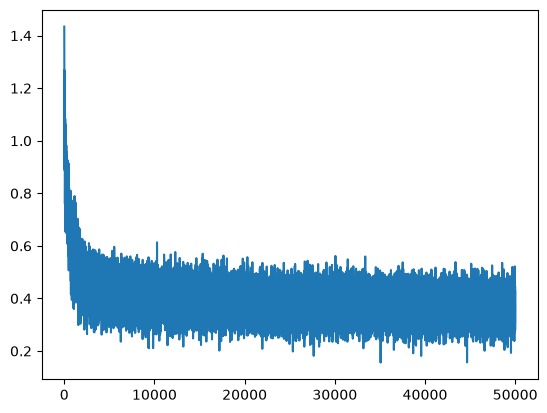

In [269]:
plt.plot(stepi, lossi)

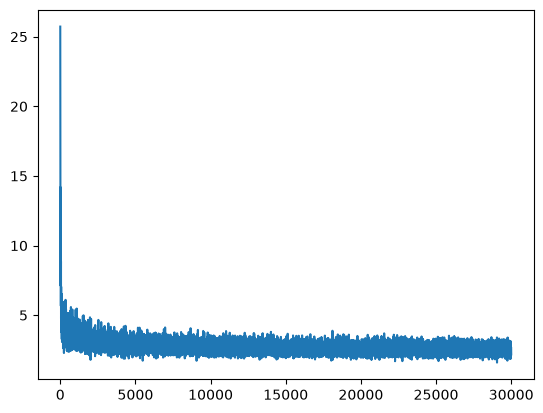

In [231]:
plt.plot(stepi, lossi)

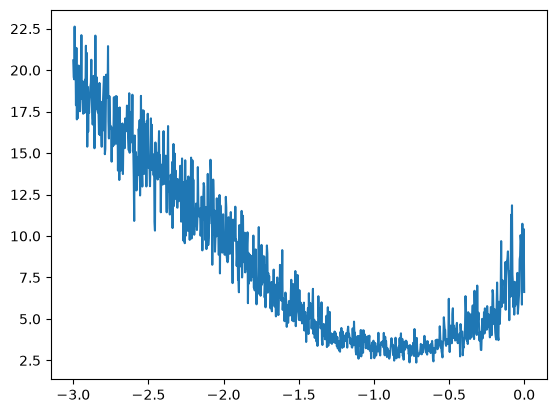

In [183]:
import matplotlib.pyplot as plt

plt.plot(lri, lossi)

In [282]:
# train set evaluation
# forward pass
emb = C[Xtr]
h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # torch infers on its own if we use -1
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ytr)
loss

tensor(2.1177, grad_fn=<NllLossBackward0>)

In [283]:
# val set evaluation
# forward pass
emb = C[Xdev]
h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # torch infers on its own if we use -1
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.1633, grad_fn=<NllLossBackward0>)

In [ ]:
# train, val, test split
# 80%, 10%, 10%

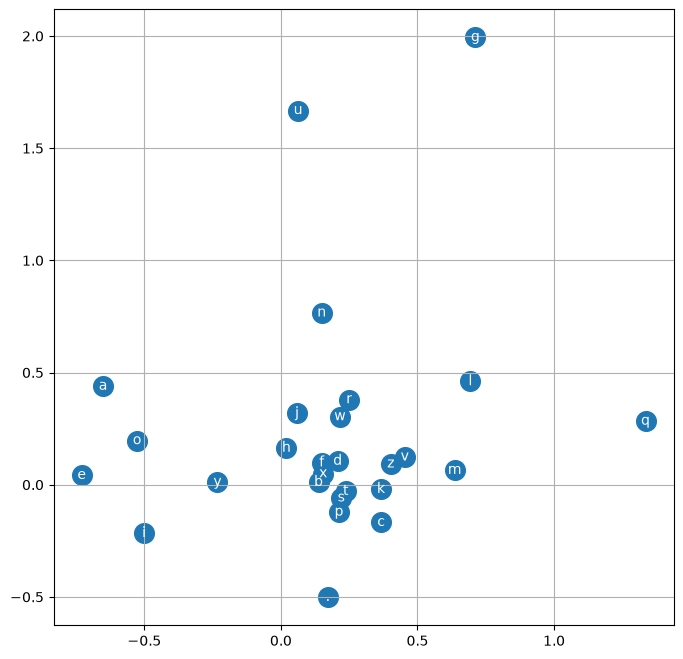

In [243]:
plt.figure(figsize=(8, 8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i, 0].item(), C[i, 1].item(), itos[i], ha="center", va="center", color="white")
plt.grid('minor')

In [284]:
# sample from the model

# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      emb = C[torch.tensor([context])] # (1,block_size,d)
      h = torch.tanh(emb.view(1, -1) @ W1 + b1)
      logits = h @ W2 + b2
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out))


mora.
kayah.
seel.
nihah.
larethastendraeg.
adelyn.
elin.
shi.
jen.
eden.
estanarvelyn.
malaia.
noshubergiairiel.
kindreth.
konni.
adrius.
kaven.
kylene.
eli.
kay.
